[2026-06-26 02:26:06] [info     ] Calculating factor for period: 2024-01-01 00:00:00 to 2025-12-31 23:59:59
[2026-06-26 02:26:07] [warning  ] bigalpha_factorminer._latest version='v12' (use ._latest for dev only, not for prod)
[2026-06-26 02:26:07] [info     ] bigalpha_factorminer.v12 开始运行 ..
[2026-06-26 02:26:07] [info     ] 未提供因子池，只进行单因子分析
[2026-06-26 02:26:07] [info     ] 单因子时间范围: 2024-01-02 至 2025-12-31
[2026-06-26 02:26:07] [info     ] ========== 数据检查 ==========
[2026-06-26 02:26:07] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor']
[2026-06-26 02:26:07] [info     ] 通过：instrument 格式检查
[2026-06-26 02:26:07] [info     ] 通过：factor 有限值检查（禁止 inf/-inf）
[2026-06-26 02:26:07] [info     ] 通过：时间范围检查
[2026-06-26 02:26:07] [info     ] 通过：交易日完整性检查
[2026-06-26 02:26:07] [info     ] 通过：唯一性检查
[2026-06-26 02:26:07] [info     ] 通过：股票池范围检查（中证1000历史成分）
[2026-06-26 02:26:08] [info     ] 通过：覆盖度检查（每交易日缺失率<=40%）
[2026-06-26 02:26:08] [info     ] ========== 数据预处理 ==========
[2026-06-

时段,IC
2024-01-15~2024-02-08,0.0149
2024-09-24~2024-10-08,0.0227
2025-04-07~2025-04-30,0.0288

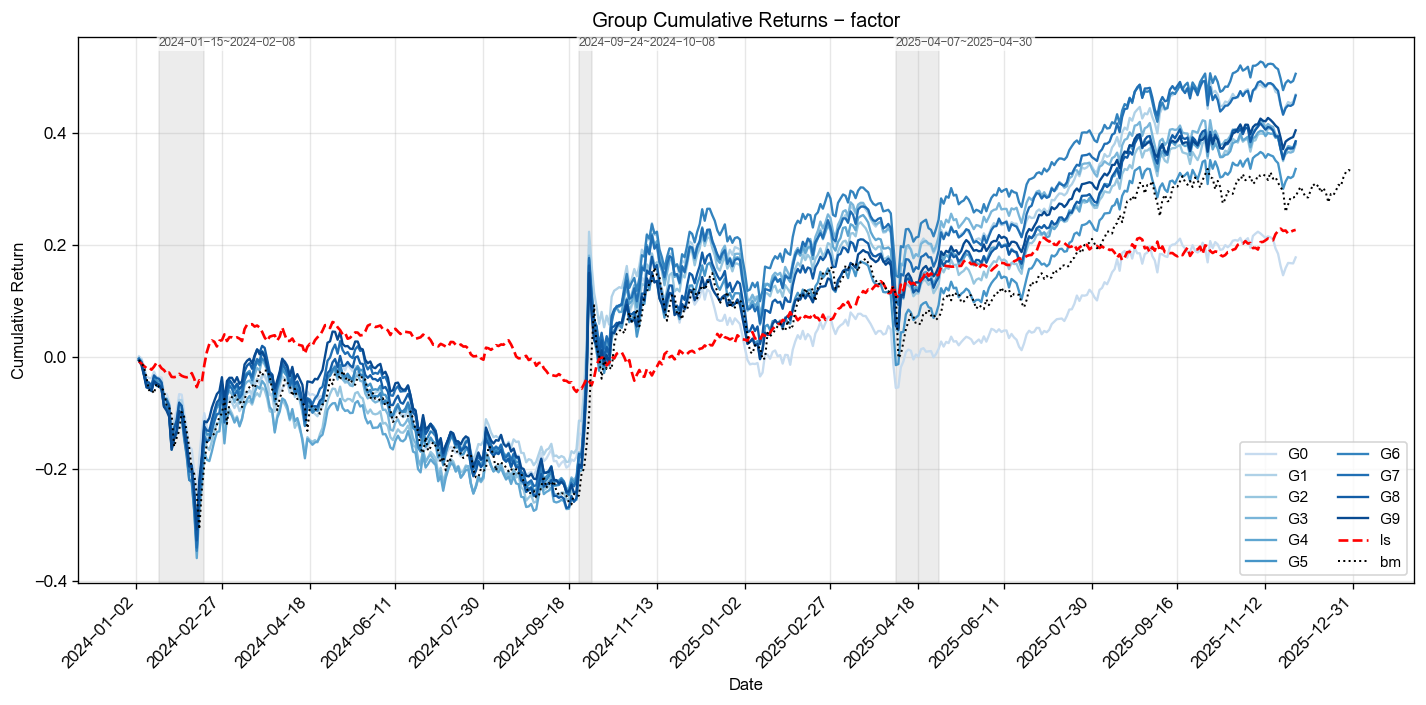
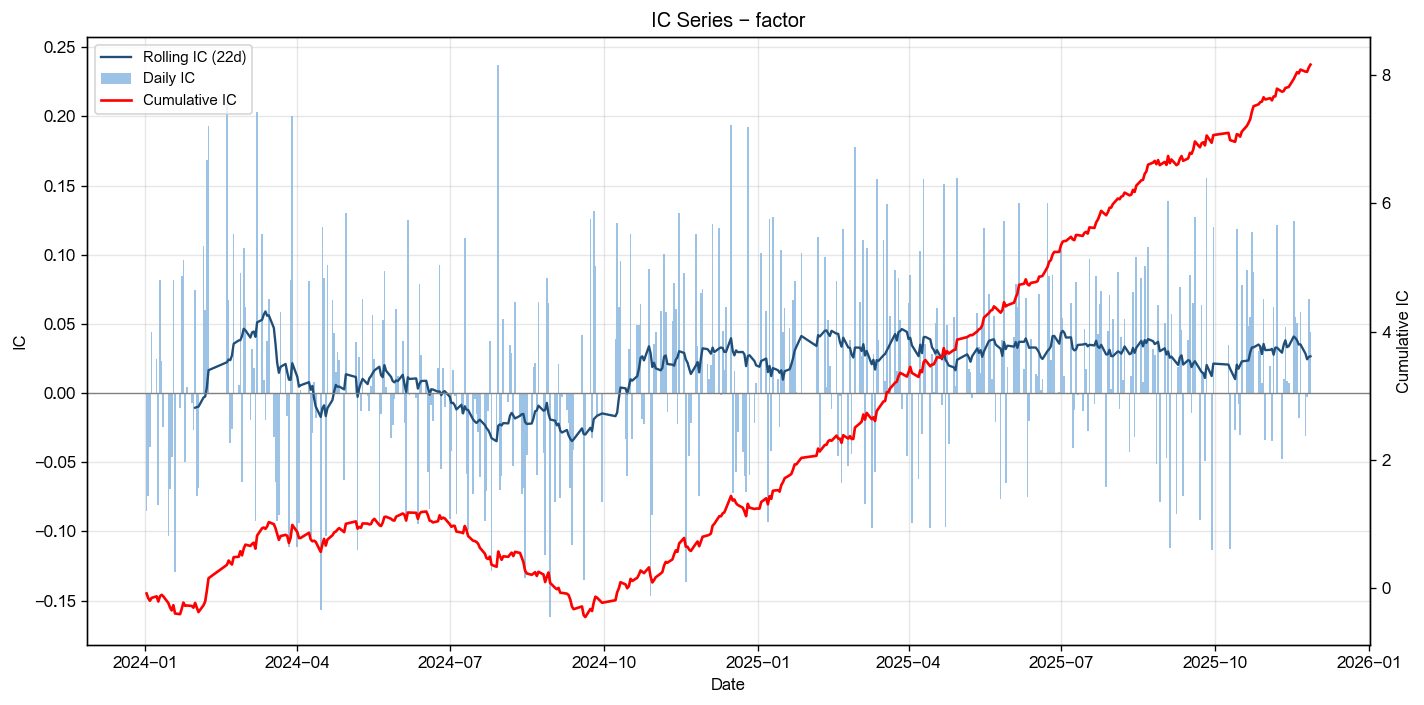
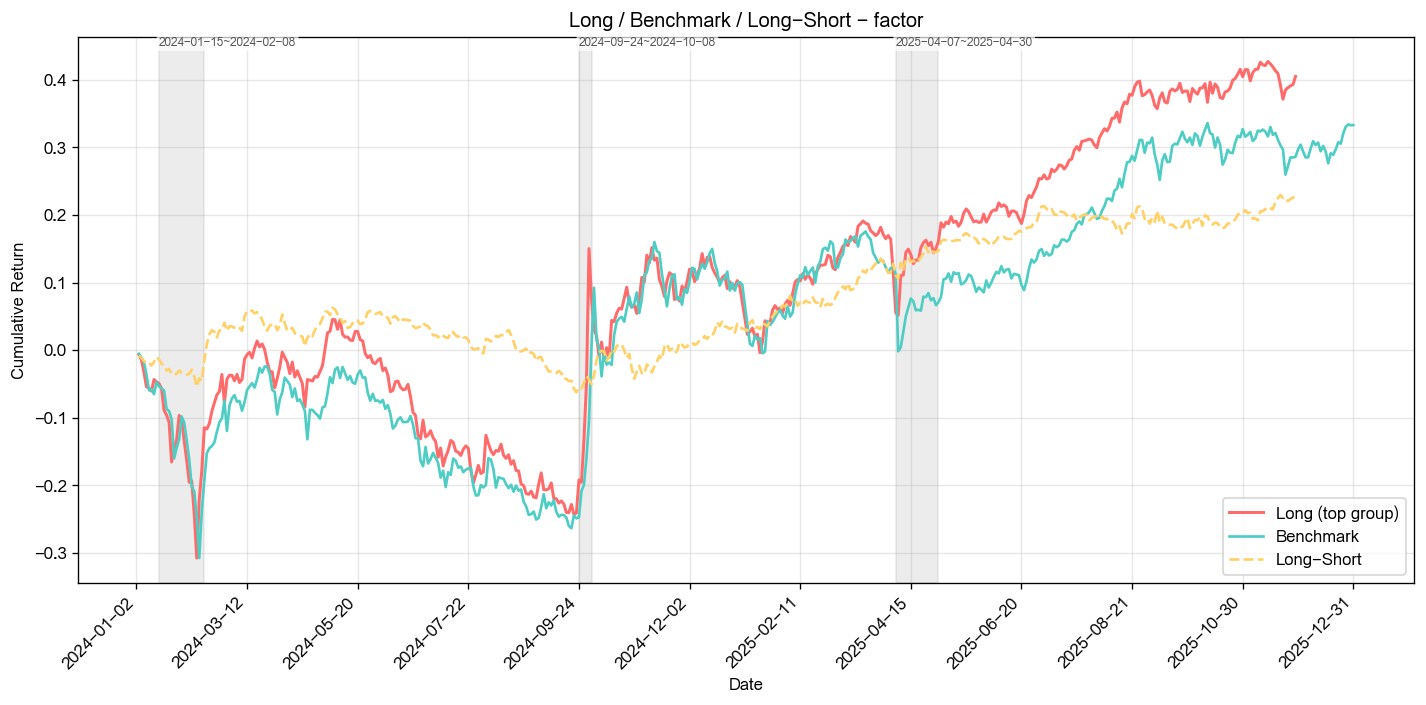
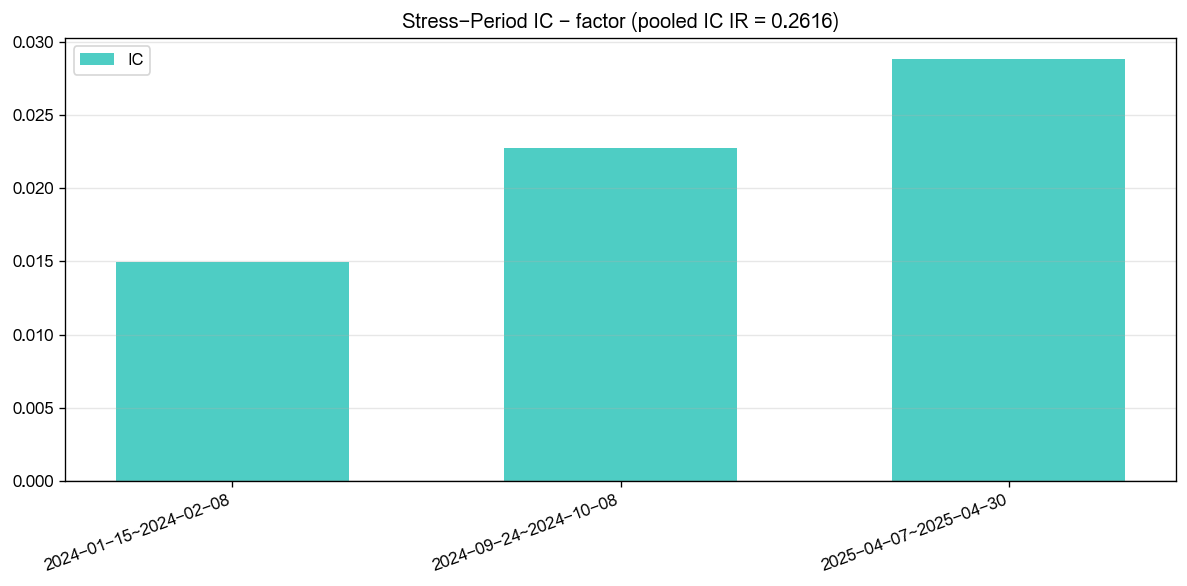
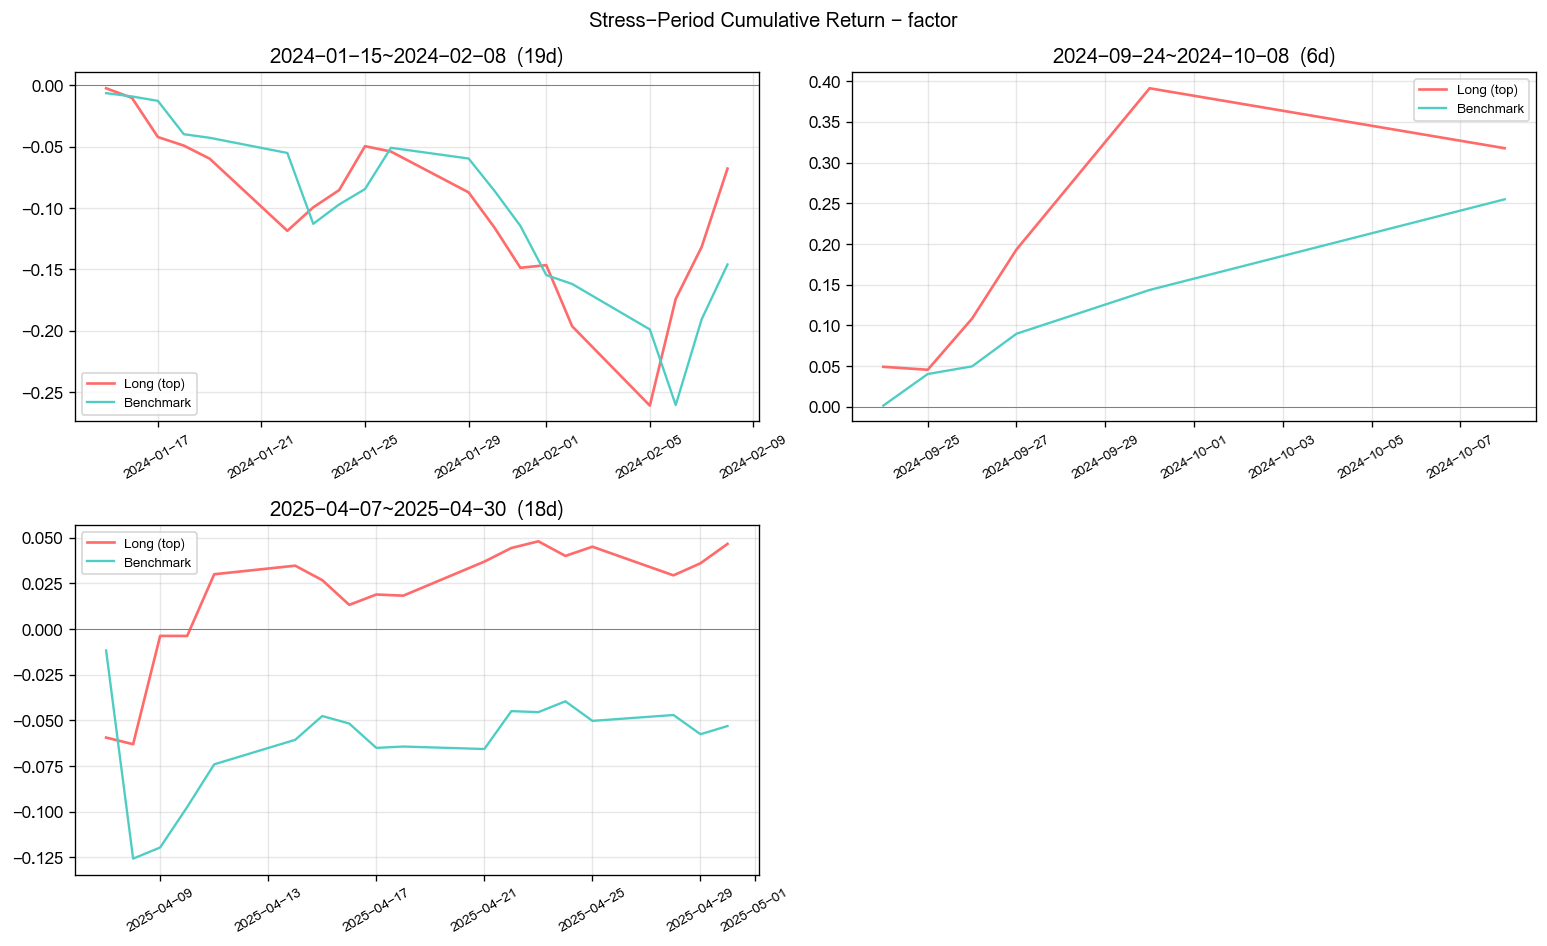

[2026-06-26 02:33:12] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-06-26 02:33:13] [warning  ] 返回的Outputs实例(size=71304821) 大于 64K, 将不会被缓存
[2026-06-26 02:33:13] [info     ] bigalpha_factorminer.v12 运行完成 [425.721s].


In [3]:
def main(datasource, start_date, end_date):
    """
    factor function

    Args:
        datasource (str): Datasource table name
        start_date (str): Start date in 'YYYY-MM-DD HH:MM:SS' format
        end_date (str): End date in 'YYYY-MM-DD HH:MM:SS' format

    Returns:
        pd.DataFrame: Factor data with columns ['date', 'instrument', 'factor']
    """
    import pandas as pd
    import dai

    # This function demonstrates how to:
    # 1. Query market from the specified datasource
    # 2. Calculate a simple factor using SQL aggregation
    # 3. Return properly formatted factor data for analysis

    # 因子公式 https://bigquant.com/wiki/doc/Rceb2JQBdS
    # This represents the volume-weighted average price (VWAP): sum(amount) / sum(volume)

    # 不依赖平台注入的 datasource,直接查日频表(更简单、不爆内存)
    sql = """
        SELECT
            b.date,
            b.instrument,
            -1 * (SUM(b.change_ratio) OVER w) / (AVG(b.turn) OVER w + 1e-6) AS factor
        FROM bigalpha_2026_bar1d AS b
        -- 只保留当日中证1000成分股
        INNER JOIN bigalpha_2026_instruments AS u
            ON b.date = u.date AND b.instrument = u.instrument
        WINDOW w AS (
            PARTITION BY b.instrument
            ORDER BY b.date
            ROWS BETWEEN 4 PRECEDING AND CURRENT ROW
        )
        QUALIFY factor IS NOT NULL
        ORDER BY b.date, b.instrument
    """
    query_start = pd.to_datetime(start_date) - pd.Timedelta(days=15)
    df = dai.query(sql, filters={'date': [query_start, end_date]}, compression=True).df()
    df = df[df['date'].between(start_date, end_date)]
    return df


if __name__ == '__main__':
    """
    FOR Development in __main__

    This section demonstrates how to:
    1. Calculate factors using the main() function
    2. Visualize and analyze results using the factorlens module

    Tips:
        - Adjust the date range to test different time periods
        - Modify the SQL query in main() to create your own factors
        - Use factorlens to evaluate factor performance metrics
    """
    from bigmodule import M
    import structlog

    logger = structlog.get_logger()

    datasource = 'bigalpha_2026_bar1d'
    start_date = '2024-01-01 00:00:00'
    end_date = '2025-12-31 23:59:59'

    logger.info(f"Calculating factor for period: {start_date} to {end_date}")
    factor_data = main(datasource, start_date, end_date)

    result = M.bigalpha_factorminer._latest(
        factor_data=factor_data,
        show=True,
    )
